# XGBoost Explainability — SHAP & Counterfactual Analysis
## MS Subtype Classification (RRMS, SPMS, PPMS)

---

### Objective

This notebook provides a **complete explainability analysis** of the XGBoost classifier for MS subtype prediction using two complementary techniques:

| Technique | Question Answered | Output |
|-----------|------------------|--------|
| **SHAP** | *Why did the model make this prediction?* | Feature contributions (direction + magnitude) |
| **Counterfactual (DiCE)** | *What would change the prediction?* | Actionable feature modifications |

### Subtypes

- **RRMS** — Relapsing-Remitting MS (most common, defined by clinical relapses)
- **SPMS** — Secondary Progressive MS (evolves from RRMS, gradual worsening)
- **PPMS** — Primary Progressive MS (progressive from onset, zero relapses)

---

## 1. Setup and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import dice_ml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = {'PPMS': '#4CAF50', 'RRMS': '#2196F3', 'SPMS': '#FF5722'}
ORDER = ['RRMS', 'SPMS', 'PPMS']

print(f"SHAP version: {shap.__version__}")
print("Setup complete.")

SHAP version: 0.51.0
Setup complete.


---
## 2. Data Preparation & XGBoost Model

We load the MS dataset (525 samples, 16 features), preprocess, and train the XGBoost classifier.

In [2]:
# Load and prepare data
df = pd.read_csv('../datasets/ms_dataset.csv')
feature_cols = [c for c in df.columns if c != 'subtype']
X = df[feature_cols]
y = df['subtype']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

# Imputation
imputer = SimpleImputer(strategy='median')
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_ready = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)
sample_weights = compute_sample_weight('balanced', y_train)

print(f"Train: {X_train_ready.shape}, Test: {X_test_ready.shape}")
print(f"Classes: {list(class_names)}")
print(f"Class distribution (test): {dict(zip(class_names, np.bincount(y_test)))}")

Train: (420, 16), Test: (105, 16)
Classes: ['PPMS', 'RRMS', 'SPMS']
Class distribution (test): {'PPMS': np.int64(25), 'RRMS': np.int64(55), 'SPMS': np.int64(25)}


In [3]:
# Train XGBoost
model = XGBClassifier(
    objective='multi:softprob', n_estimators=300,
    learning_rate=0.1, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE, n_jobs=-1
)
model.fit(X_train_ready, y_train, sample_weight=sample_weights, verbose=False)

y_pred = model.predict(X_test_ready)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Accuracy: 0.8952
Test Macro F1: 0.8698

              precision    recall  f1-score   support

        PPMS     0.7857    0.8800    0.8302        25
        RRMS     0.9811    0.9455    0.9630        55
        SPMS     0.8333    0.8000    0.8163        25

    accuracy                         0.8952       105
   macro avg     0.8667    0.8752    0.8698       105
weighted avg     0.8994    0.8952    0.8964       105



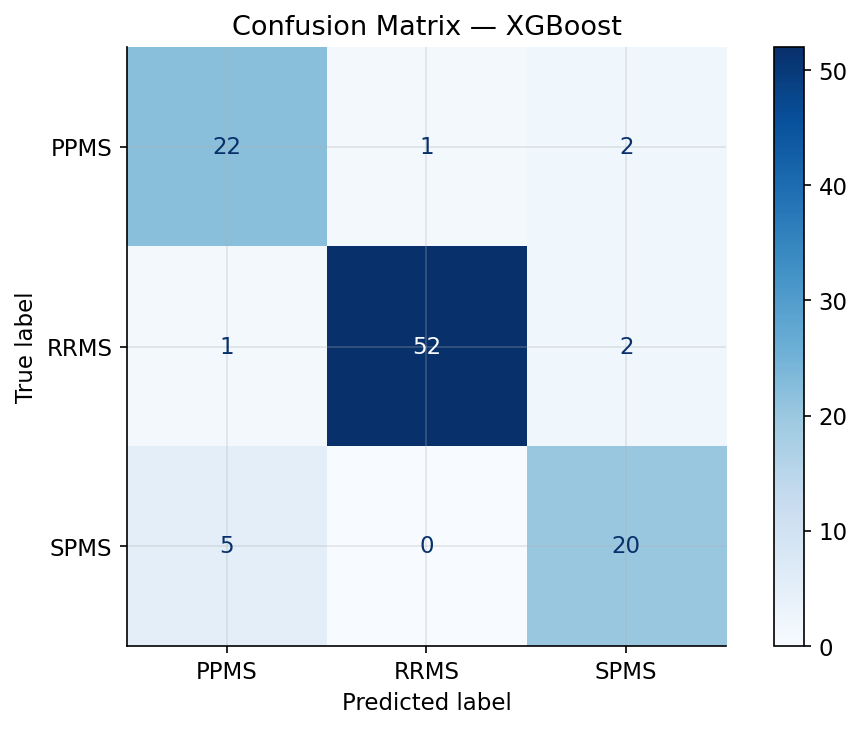

In [4]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

---
# Part A: SHAP Explainability

SHAP (SHapley Additive exPlanations) uses game theory to assign each feature a contribution score for every prediction. For tree models, `TreeExplainer` computes **exact** Shapley values efficiently.

---

## 3. Computing SHAP Values

In [5]:
# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test_ready)

# Handle different SHAP output formats
if isinstance(shap_values_raw, list):
    shap_values_list = shap_values_raw
elif shap_values_raw.ndim == 3:
    shap_values_list = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    shap_values_list = [shap_values_raw]

print(f"SHAP computed for {len(shap_values_list)} classes, shape per class: {shap_values_list[0].shape}")
print(f"Classes: {list(class_names)}")

SHAP computed for 3 classes, shape per class: (105, 16)
Classes: ['PPMS', 'RRMS', 'SPMS']


---
## 4. Global Feature Importance

Mean |SHAP| across all test samples and classes — shows which features matter most **overall**.

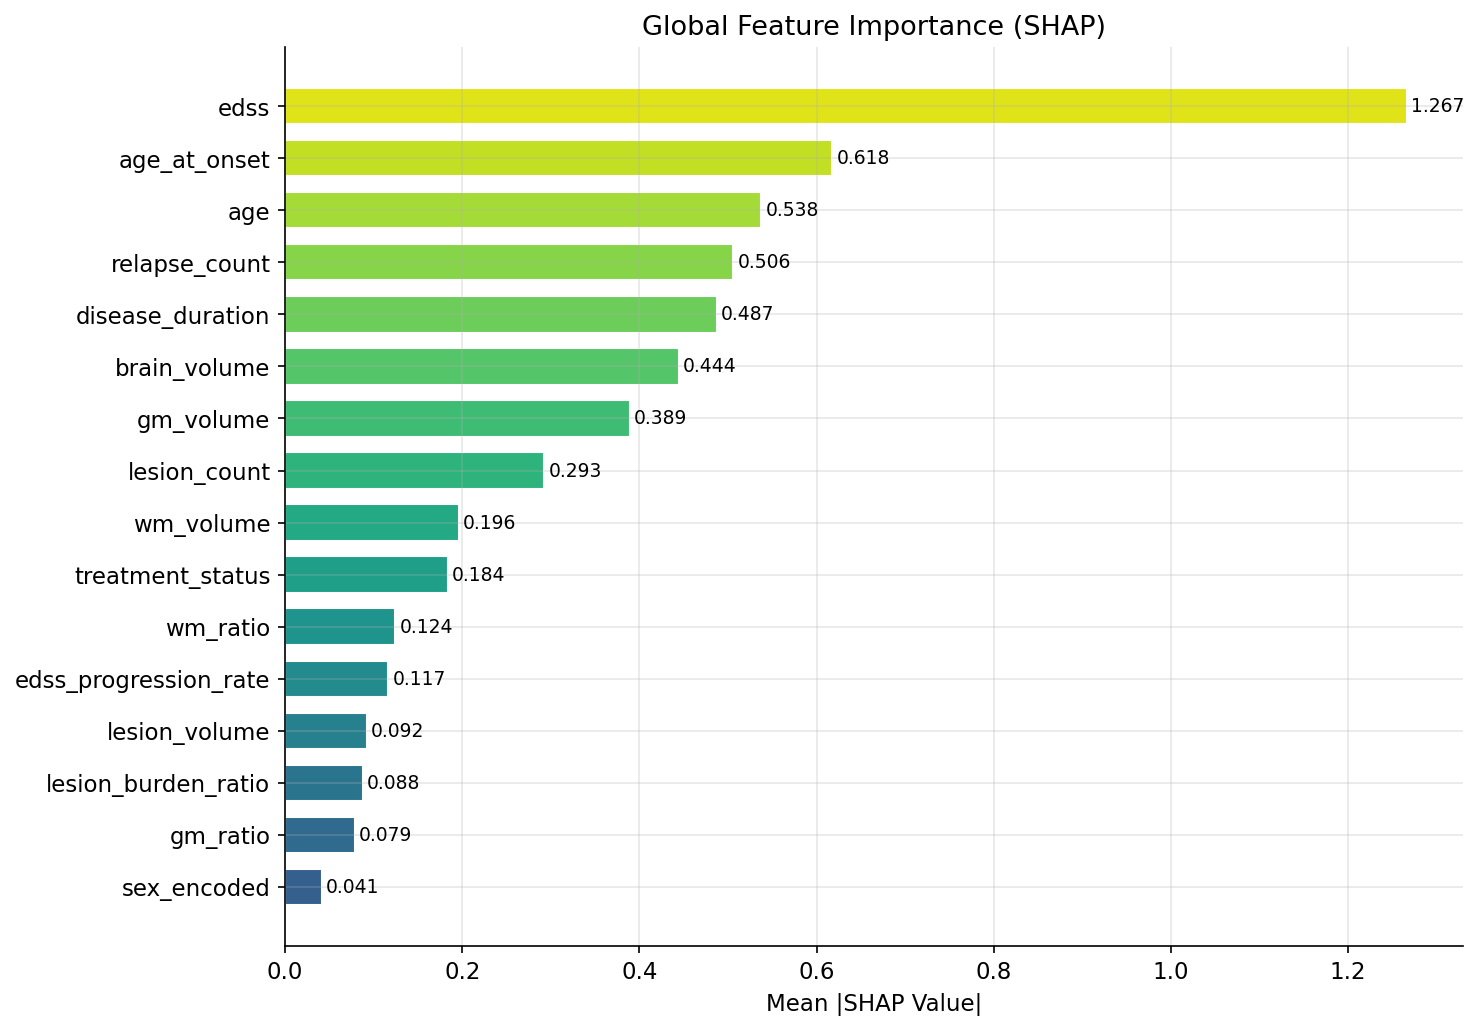


Feature Importance Ranking:
   1. edss                           1.2667
   2. age_at_onset                   0.6175
   3. age                            0.5378
   4. relapse_count                  0.5059
   5. disease_duration               0.4873
   6. brain_volume                   0.4443
   7. gm_volume                      0.3890
   8. lesion_count                   0.2928
   9. wm_volume                      0.1961
  10. treatment_status               0.1837
  11. wm_ratio                       0.1241
  12. edss_progression_rate          0.1167
  13. lesion_volume                  0.0922
  14. lesion_burden_ratio            0.0877
  15. gm_ratio                       0.0787
  16. sex_encoded                    0.0412


In [6]:
# Global feature importance: mean |SHAP| across all classes
shap_abs_mean = np.zeros(len(feature_cols))
for sv in shap_values_list:
    shap_abs_mean += np.abs(sv).mean(axis=0)
shap_abs_mean /= len(shap_values_list)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': shap_abs_mean
}).sort_values('Mean |SHAP|', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.3, 0.95, len(importance_df)))
ax.barh(importance_df['Feature'], importance_df['Mean |SHAP|'],
        color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Global Feature Importance (SHAP)')
for i, (feat, val) in enumerate(zip(importance_df['Feature'], importance_df['Mean |SHAP|'])):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Print ranking
print("\nFeature Importance Ranking:")
for rank, (_, row) in enumerate(importance_df.sort_values('Mean |SHAP|', ascending=False).iterrows(), 1):
    print(f"  {rank:2d}. {row['Feature']:30s} {row['Mean |SHAP|']:.4f}")

---
## 5. SHAP Summary Plots Per Class

Summary (beeswarm) plots show **every test sample** as a dot. The x-axis is the SHAP value (impact on prediction), and color indicates the feature value (red = high, blue = low).

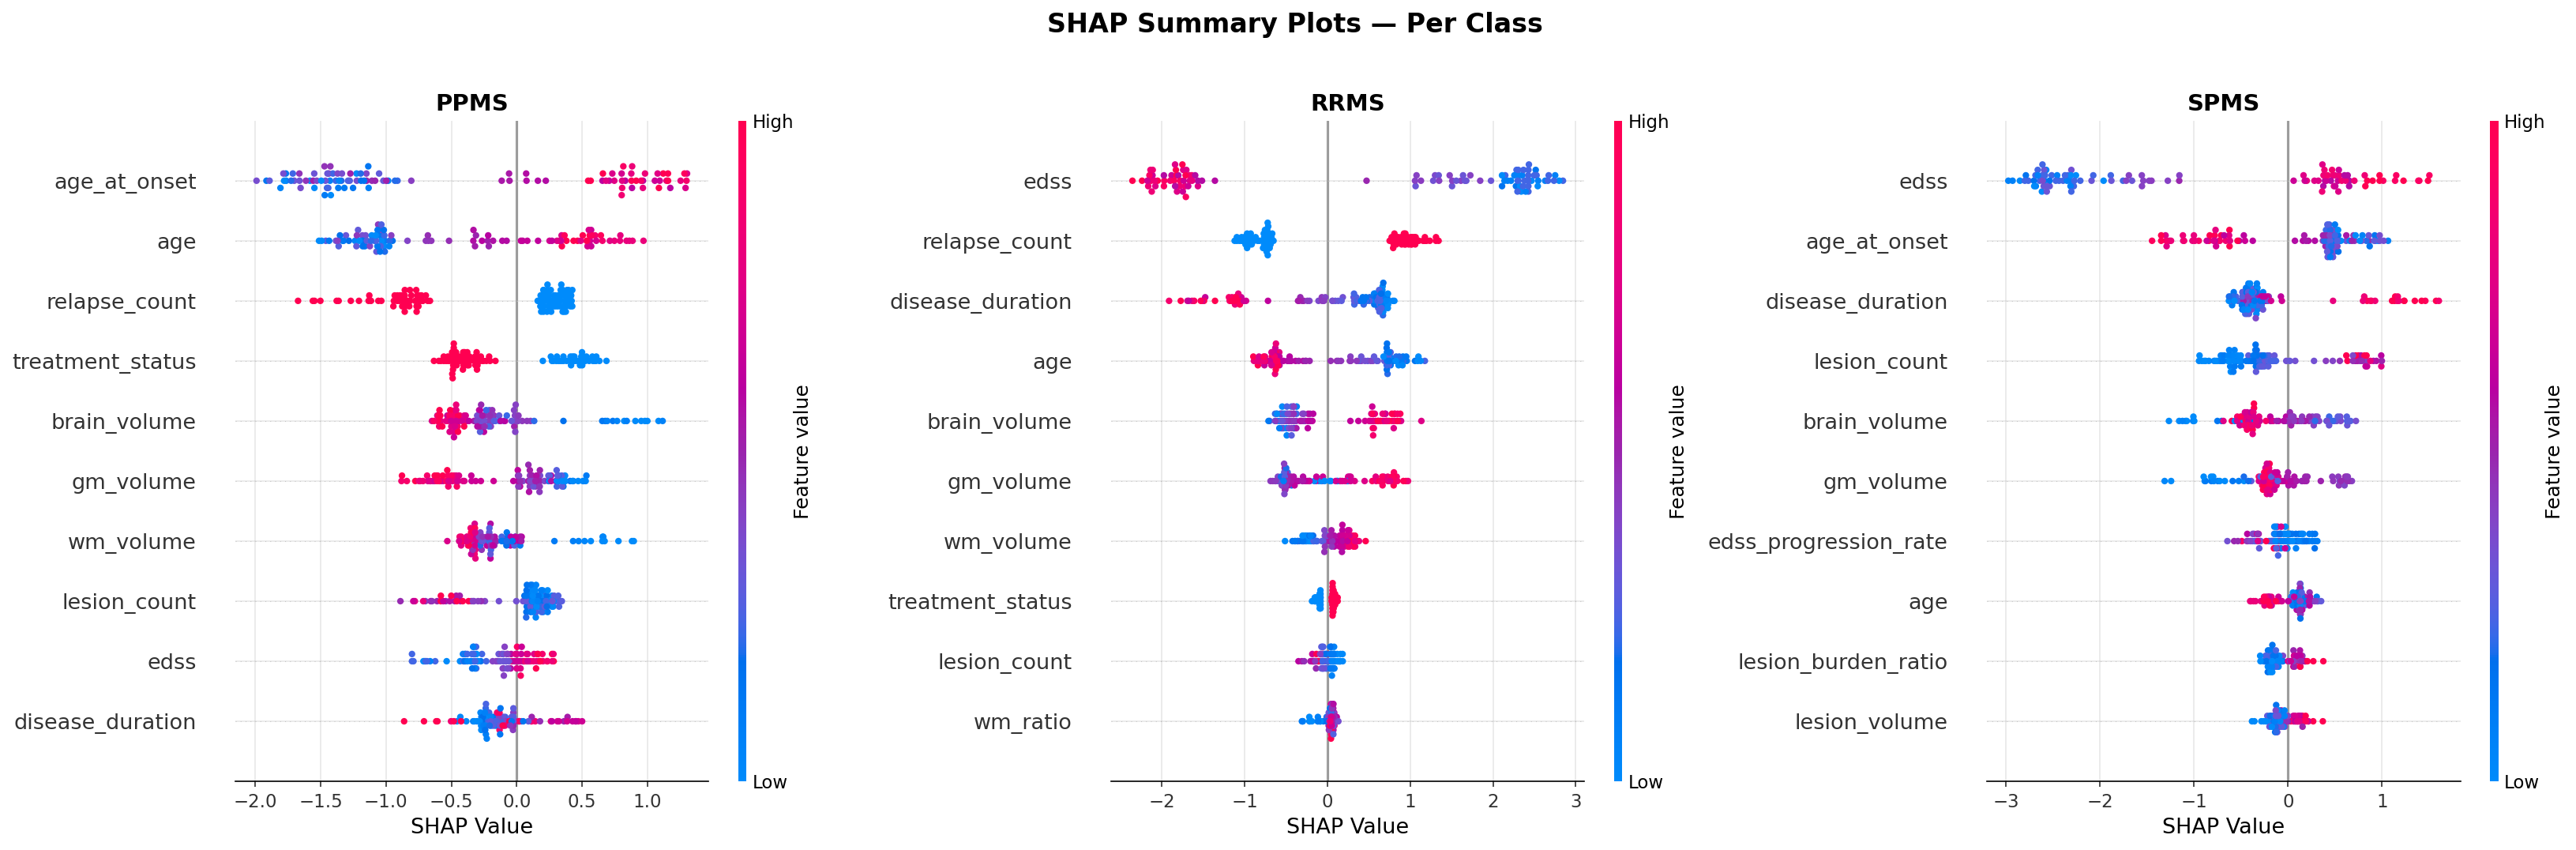

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, name in enumerate(class_names):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values_list[i], X_test_ready,
        max_display=10, show=False, plot_size=None
    )
    axes[i].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('SHAP Value')

plt.suptitle('SHAP Summary Plots — Per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Clinical Interpretation

- **RRMS:** Low EDSS (blue dots on right) strongly pushes toward RRMS → low disability = relapsing-remitting
- **PPMS:** Late age at onset and older age push toward PPMS → late, progressive onset
- **SPMS:** High EDSS and long disease duration push toward SPMS → accumulated disability over time

---
## 6. Individual Patient Explanations (Waterfall Plots)

Waterfall plots show the **step-by-step reasoning** for a single prediction — starting from the base value and adding each feature's contribution.

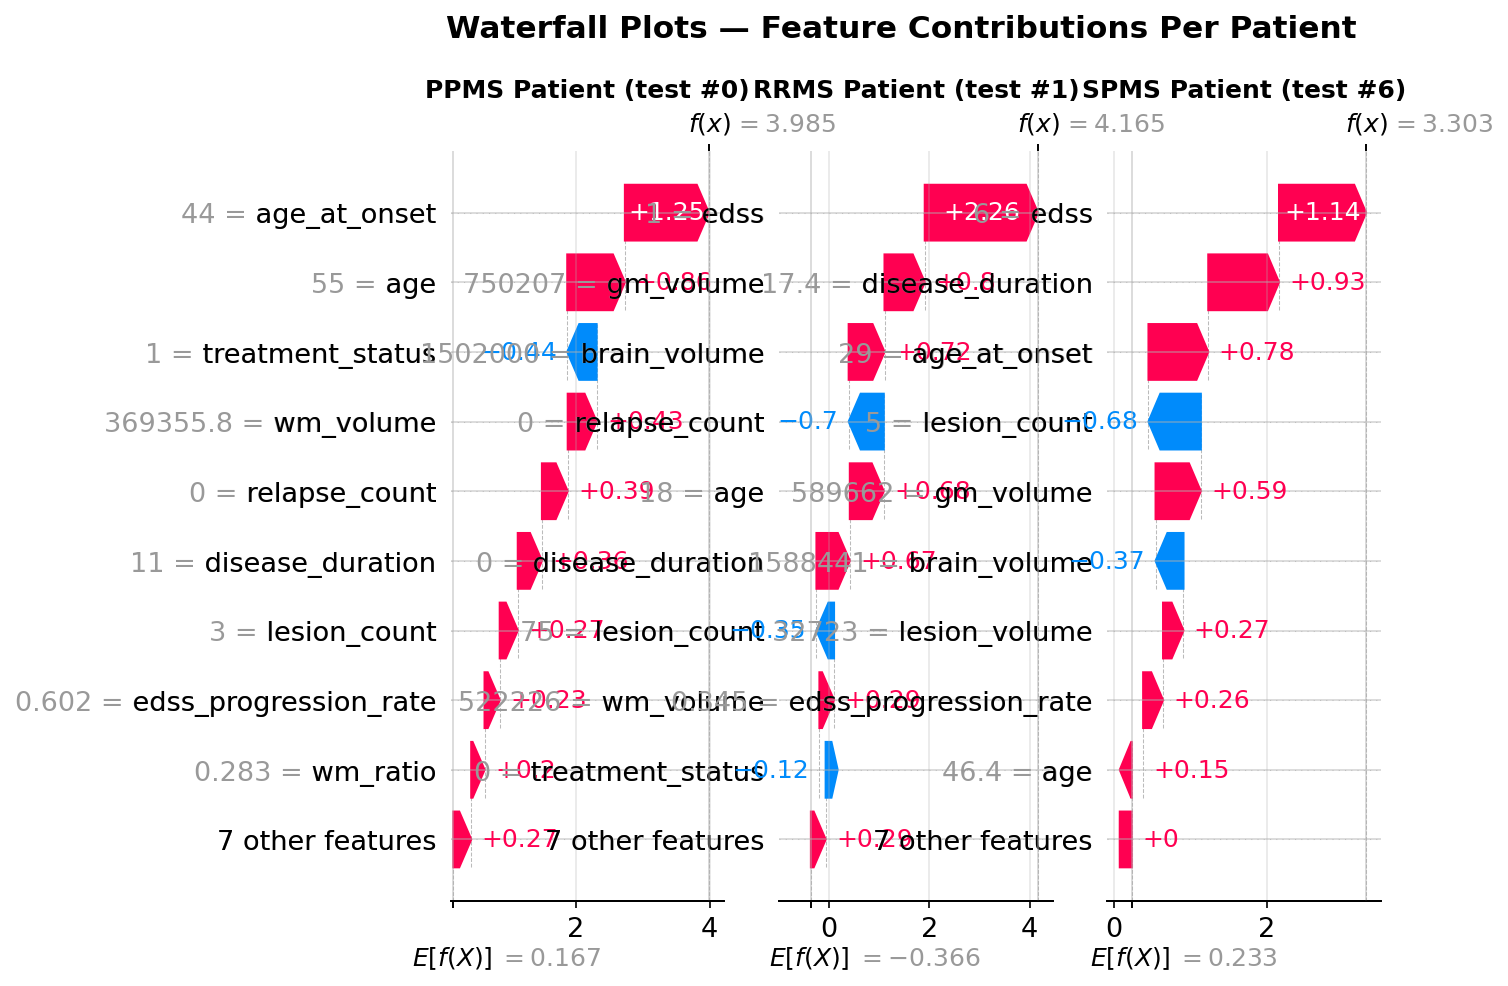


--- PPMS Patient (test index 0) ---
  Top features pushing TOWARD PPMS:
    age_at_onset: +1.2539 (value=44.00)
    age: +0.8617 (value=55.00)
    wm_volume: +0.4313 (value=369355.80)
  Top features pushing AWAY from PPMS:
    treatment_status: -0.4382 (value=1.00)
    lesion_burden_ratio: -0.0971 (value=0.01)
    edss: -0.0691 (value=3.50)

--- RRMS Patient (test index 1) ---
  Top features pushing TOWARD RRMS:
    edss: +2.2586 (value=1.00)
    gm_volume: +0.8031 (value=750207.00)
    brain_volume: +0.7155 (value=1502000.00)
  Top features pushing AWAY from RRMS:
    relapse_count: -0.7002 (value=0.00)
    lesion_count: -0.3504 (value=75.00)
    treatment_status: -0.1242 (value=0.00)

--- SPMS Patient (test index 6) ---
  Top features pushing TOWARD SPMS:
    edss: +1.1391 (value=6.00)
    disease_duration: +0.9263 (value=17.40)
    age_at_onset: +0.7826 (value=29.00)
  Top features pushing AWAY from SPMS:
    lesion_count: -0.6849 (value=5.00)
    brain_volume: -0.3653 (value=15884

In [8]:
# Select one correctly classified patient per subtype
y_pred_test = model.predict(X_test_ready)
patient_indices = {}

for class_idx, name in enumerate(class_names):
    mask = (y_test == class_idx) & (y_pred_test == class_idx)
    if mask.sum() > 0:
        patient_indices[name] = np.where(mask)[0][0]

# Compute SHAP Explanation object for waterfall plots
shap_explanation = explainer(X_test_ready)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax_idx, (name, pidx) in enumerate(patient_indices.items()):
    plt.sca(axes[ax_idx])
    class_idx = list(class_names).index(name)
    
    # Build single-row Explanation for the predicted class
    exp_single = shap.Explanation(
        values=shap_explanation.values[pidx, :, class_idx],
        base_values=shap_explanation.base_values[pidx, class_idx],
        data=shap_explanation.data[pidx],
        feature_names=feature_cols
    )
    shap.plots.waterfall(exp_single, max_display=10, show=False)
    axes[ax_idx].set_title(f'{name} Patient (test #{pidx})', fontsize=12, fontweight='bold')

plt.suptitle('Waterfall Plots — Feature Contributions Per Patient', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed attribution
for name, pidx in patient_indices.items():
    class_idx = list(class_names).index(name)
    sv = shap_values_list[class_idx][pidx]
    top_pos = np.argsort(sv)[-3:][::-1]
    top_neg = np.argsort(sv)[:3]
    print(f"\n--- {name} Patient (test index {pidx}) ---")
    print(f"  Top features pushing TOWARD {name}:")
    for j in top_pos:
        if sv[j] > 0:
            print(f"    {feature_cols[j]}: +{sv[j]:.4f} (value={X_test_ready.iloc[pidx][feature_cols[j]]:.2f})")
    print(f"  Top features pushing AWAY from {name}:")
    for j in top_neg:
        if sv[j] < 0:
            print(f"    {feature_cols[j]}: {sv[j]:.4f} (value={X_test_ready.iloc[pidx][feature_cols[j]]:.2f})")

---
## 7. Feature Interactions

SHAP interaction values reveal when **two features combine** to produce effects different from their individual contributions.

Interaction matrix shape: (16, 16)

Top 10 Feature Interactions:
  age_at_onset x edss: 0.0839
  edss x disease_duration: 0.0583
  age x edss: 0.0487
  edss x brain_volume: 0.0487
  age_at_onset x relapse_count: 0.0434
  edss x gm_volume: 0.0422
  age x relapse_count: 0.0422
  edss x lesion_count: 0.0401
  age_at_onset x brain_volume: 0.0378
  relapse_count x brain_volume: 0.0365


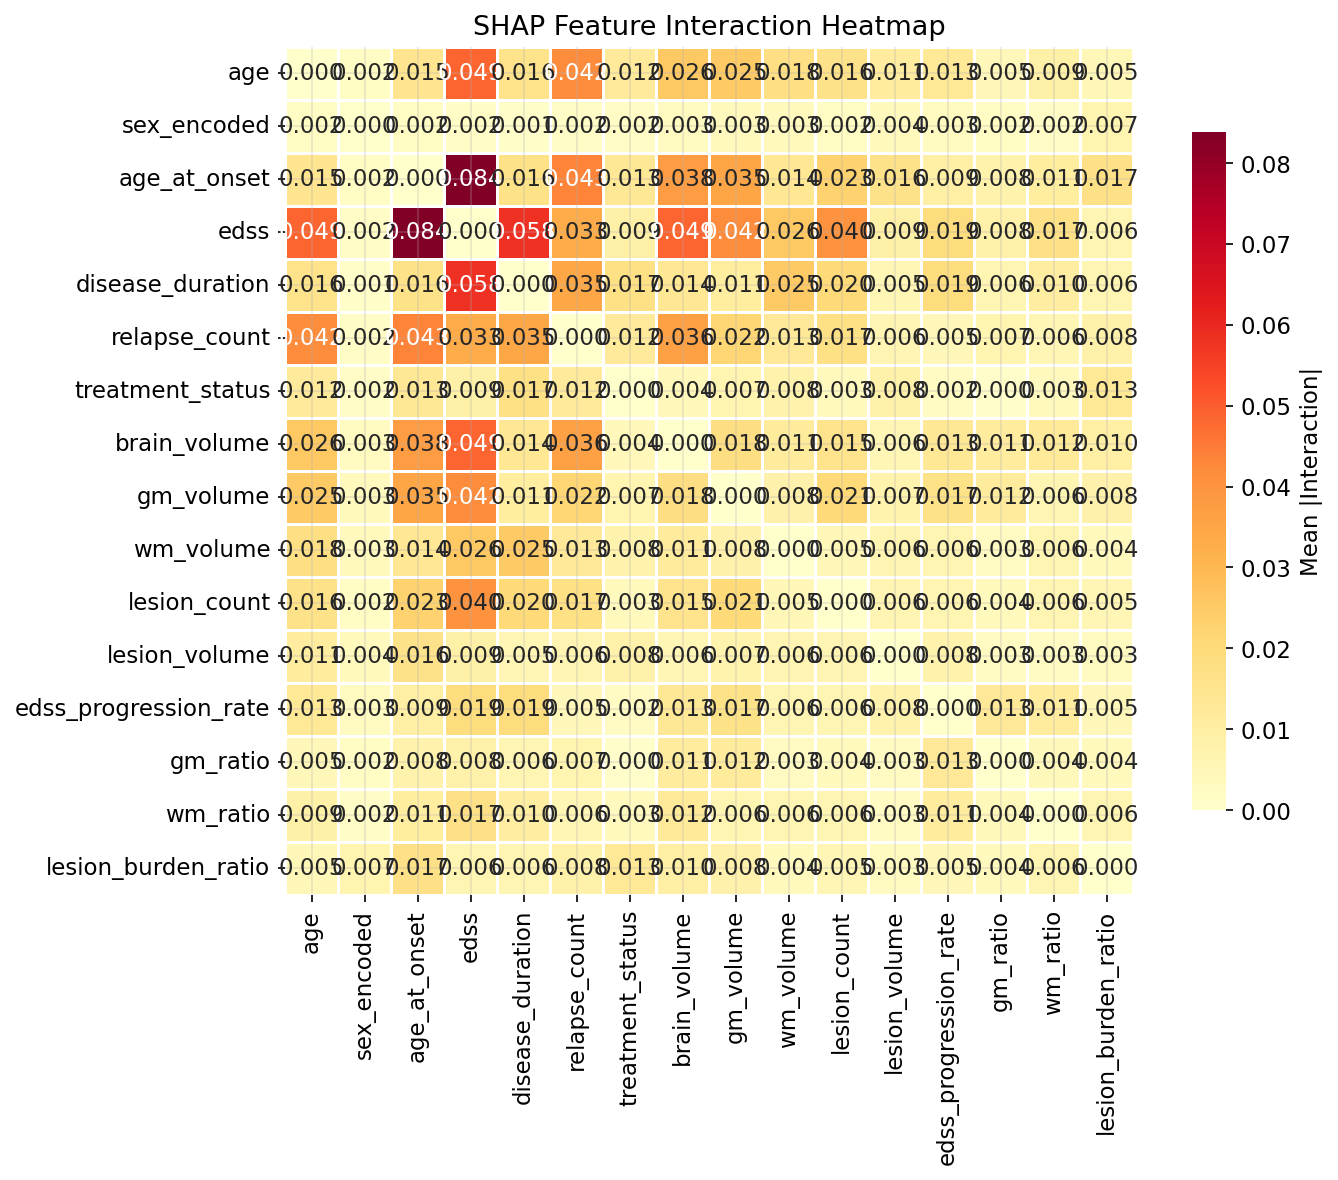

In [9]:
# Compute interaction values on a subset
n_sample = min(50, len(X_test_ready))
X_sample = X_test_ready.iloc[:n_sample]
shap_interaction = explainer.shap_interaction_values(X_sample)

# Average absolute interaction across classes and samples
if isinstance(shap_interaction, list):
    # list of arrays, one per class, each (n_samples, n_features, n_features)
    mean_interaction = np.mean([np.abs(si).mean(axis=0) for si in shap_interaction], axis=0)
elif shap_interaction.ndim == 4:
    # shape: (n_samples, n_features, n_features, n_classes)
    mean_interaction = np.abs(shap_interaction).mean(axis=(0, 3))
else:
    mean_interaction = np.abs(shap_interaction).mean(axis=0)

# Zero out diagonal (self-interactions)
np.fill_diagonal(mean_interaction, 0)

print(f"Interaction matrix shape: {mean_interaction.shape}")

# Top interactions
n_feat = mean_interaction.shape[0]
pairs = []
for i in range(n_feat):
    for j in range(i+1, n_feat):
        pairs.append((feature_cols[i], feature_cols[j], mean_interaction[i, j]))
pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop 10 Feature Interactions:")
for f1, f2, val in pairs[:10]:
    print(f"  {f1} x {f2}: {val:.4f}")

# Heatmap of top interactions
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(mean_interaction, index=feature_cols, columns=feature_cols),
            cmap='YlOrRd', annot=True, fmt='.3f', square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Mean |Interaction|'})
ax.set_title('SHAP Feature Interaction Heatmap')
plt.tight_layout()
plt.show()

---
## 8. Explaining Misclassifications

Understanding **why** the model makes mistakes is crucial for clinical trust.

In [10]:
# Find misclassified samples
misclassified = np.where(y_test != y_pred_test)[0]
print(f"Total misclassified: {len(misclassified)} out of {len(y_test)} ({100*len(misclassified)/len(y_test):.1f}%)")

for idx in misclassified[:5]:  # Show first 5
    true_class = class_names[y_test[idx]]
    pred_class = class_names[y_pred_test[idx]]
    pred_class_idx = y_pred_test[idx]
    sv = shap_values_list[pred_class_idx][idx]
    top_contributors = np.argsort(sv)[-3:][::-1]
    
    print(f"\nPatient {idx}: True={true_class}, Predicted={pred_class}")
    print(f"  Features pushing toward {pred_class} (wrong):")
    for j in top_contributors:
        print(f"    {feature_cols[j]}: SHAP={sv[j]:+.4f}, value={X_test_ready.iloc[idx][feature_cols[j]]:.2f}")

Total misclassified: 11 out of 105 (10.5%)

Patient 9: True=PPMS, Predicted=RRMS
  Features pushing toward RRMS (wrong):
    edss: SHAP=+2.8455, value=2.00
    disease_duration: SHAP=+0.7891, value=1.00
    gm_volume: SHAP=+0.7570, value=687551.40

Patient 43: True=SPMS, Predicted=PPMS
  Features pushing toward PPMS (wrong):
    brain_volume: SHAP=+0.7681, value=1100956.00
    age_at_onset: SHAP=+0.7314, value=42.00
    age: SHAP=+0.6440, value=62.10

Patient 45: True=PPMS, Predicted=SPMS
  Features pushing toward SPMS (wrong):
    disease_duration: SHAP=+1.1797, value=17.60
    age_at_onset: SHAP=+1.0168, value=30.00
    edss: SHAP=+0.5316, value=4.50

Patient 50: True=PPMS, Predicted=SPMS
  Features pushing toward SPMS (wrong):
    disease_duration: SHAP=+0.8764, value=19.00
    lesion_count: SHAP=+0.7855, value=61.00
    edss: SHAP=+0.3657, value=5.00

Patient 54: True=SPMS, Predicted=PPMS
  Features pushing toward PPMS (wrong):
    brain_volume: SHAP=+1.1162, value=1109040.00
    a

---
# Part B: Counterfactual Explanations (DiCE)

Counterfactuals answer: *"What would need to change about this patient for the model to predict a different subtype?"*

While SHAP looks **backward** (why was this predicted?), counterfactuals look **forward** (what would change it?).

---

## 9. Setting Up DiCE

In [11]:
# Prepare data for DiCE (integer-encoded labels)
train_for_dice = X_train_ready.copy()
train_for_dice['subtype'] = y_train

continuous_features = [c for c in feature_cols if c not in ['sex_encoded', 'treatment_status']]
class_index_map = {name: idx for idx, name in enumerate(class_names)}

# Create DiCE objects
dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=continuous_features,
    outcome_name='subtype'
)
dice_model = dice_ml.Model(model=model, backend='sklearn')
dice_exp = dice_ml.Dice(dice_data, dice_model, method='random')

print(f"DiCE ready. Continuous features: {len(continuous_features)}")
print(f"Class mapping: {class_index_map}")

DiCE ready. Continuous features: 14
Class mapping: {'PPMS': 0, 'RRMS': 1, 'SPMS': 2}


---
## 10. Counterfactual Explanations Per Subtype

For each correctly classified patient, we generate counterfactuals showing what would need to change to flip the prediction to a clinically relevant alternative subtype.

In [12]:
# Generate counterfactuals for one patient per subtype
target_map = {}
for idx_src, name_src in enumerate(class_names):
    if name_src == 'PPMS':
        target_map[idx_src] = list(class_names).index('RRMS')
    elif name_src == 'RRMS':
        target_map[idx_src] = list(class_names).index('SPMS')
    elif name_src == 'SPMS':
        target_map[idx_src] = list(class_names).index('RRMS')

cf_results = {}

for class_idx, name in enumerate(class_names):
    mask = (y_test == class_idx) & (y_pred_test == class_idx)
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        patient = X_test_ready.iloc[[idx]]
        target_idx = target_map[class_idx]
        target_name = class_names[target_idx]
        
        print(f"\n{'='*60}")
        print(f"{name} Patient (test #{idx}) → Target: {target_name}")
        print(f"{'='*60}")
        
        try:
            cf = dice_exp.generate_counterfactuals(
                patient, total_CFs=3, desired_class=int(target_idx),
                features_to_vary=continuous_features, random_seed=RANDOM_STATE
            )
            cf_results[name] = {'idx': idx, 'patient': patient, 'cf': cf, 'target': target_name}
            cf.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f"  Error: {e}")
            cf_results[name] = None


PPMS Patient (test #0) → Target: RRMS


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  6.17it/s]

100%|██████████| 1/1 [00:00<00:00,  6.13it/s]

Query instance (original outcome : 0)


...

100%|██████████| 1/1 [00:00<00:00,  5.86it/s]

Query instance (original outcome : 2)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,46.400002,0.0,29.0,6.0,17.4,0.0,0.0,1588441.0,589662.0,434781.0,5.0,32723.0,0.344828,0.371221,0.273716,0.020601,2



Diverse Counterfactual set (new outcome: 1)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,2.2,9.1,-,-,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,1.3,-,-,-,-,-,-,-,-,1.55240246,0.3793,-,-,1.0
2,-,-,-,0.3,1.2,-,-,-,-,-,-,-,0.34388521,-,-,-,1.0


---
## 11. Targeted Clinical Questions

**Key clinical question:** *What would need to change for a progressive MS patient (SPMS/PPMS) to be classified as RRMS?*

This reveals the **decision boundaries** between progressive and relapsing-remitting forms.

In [13]:
# Targeted: SPMS → RRMS and PPMS → RRMS
rrms_idx = int(list(class_names).index('RRMS'))

for source_subtype in ['SPMS', 'PPMS']:
    class_idx = list(class_names).index(source_subtype)
    mask = (y_test == class_idx) & (y_pred_test == class_idx)
    if mask.sum() == 0:
        continue
    
    idx = np.where(mask)[0][0]
    patient = X_test_ready.iloc[[idx]]
    
    print(f"\n{'='*60}")
    print(f"{source_subtype} Patient → What would make them RRMS?")
    print(f"{'='*60}")
    print("Current key values:")
    for col in ['edss', 'disease_duration', 'relapse_count', 'age', 'age_at_onset']:
        print(f"  {col:30s} {patient[col].values[0]:.2f}")
    
    try:
        cf = dice_exp.generate_counterfactuals(
            patient, total_CFs=3, desired_class=rrms_idx,
            features_to_vary=continuous_features, random_seed=RANDOM_STATE
        )
        cf.visualize_as_dataframe(show_only_changes=True)
    except Exception as e:
        print(f"  Error: {e}")


SPMS Patient → What would make them RRMS?
Current key values:
  edss                           6.00
  disease_duration               17.40
  relapse_count                  0.00
  age                            46.40
  age_at_onset                   29.00


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  5.95it/s]

100%|██████████| 1/1 [00:00<00:00,  5.92it/s]

Query instance (original outcome : 2)


...

100%|██████████| 1/1 [00:00<00:00,  6.29it/s]

Query instance (original outcome : 0)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,55.0,1.0,44.0,3.5,11.0,0.0,1.0,1303211.5,583393.8125,369355.8125,3.0,17658.5,0.6016,0.4477,0.2834,0.01355,0



Diverse Counterfactual set (new outcome: 1)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,-,-,1.5,-,-,-,-,-,-,-,-,-,-,1.0
1,24.9,-,-,1.5,-,-,-,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,2.0,-,-,-,-,-,-,-,-,-,-,1.0


---
## 12. Counterfactual Feature Change Analysis

Which features change most frequently across all generated counterfactuals? These are the features sitting at **decision boundaries**.

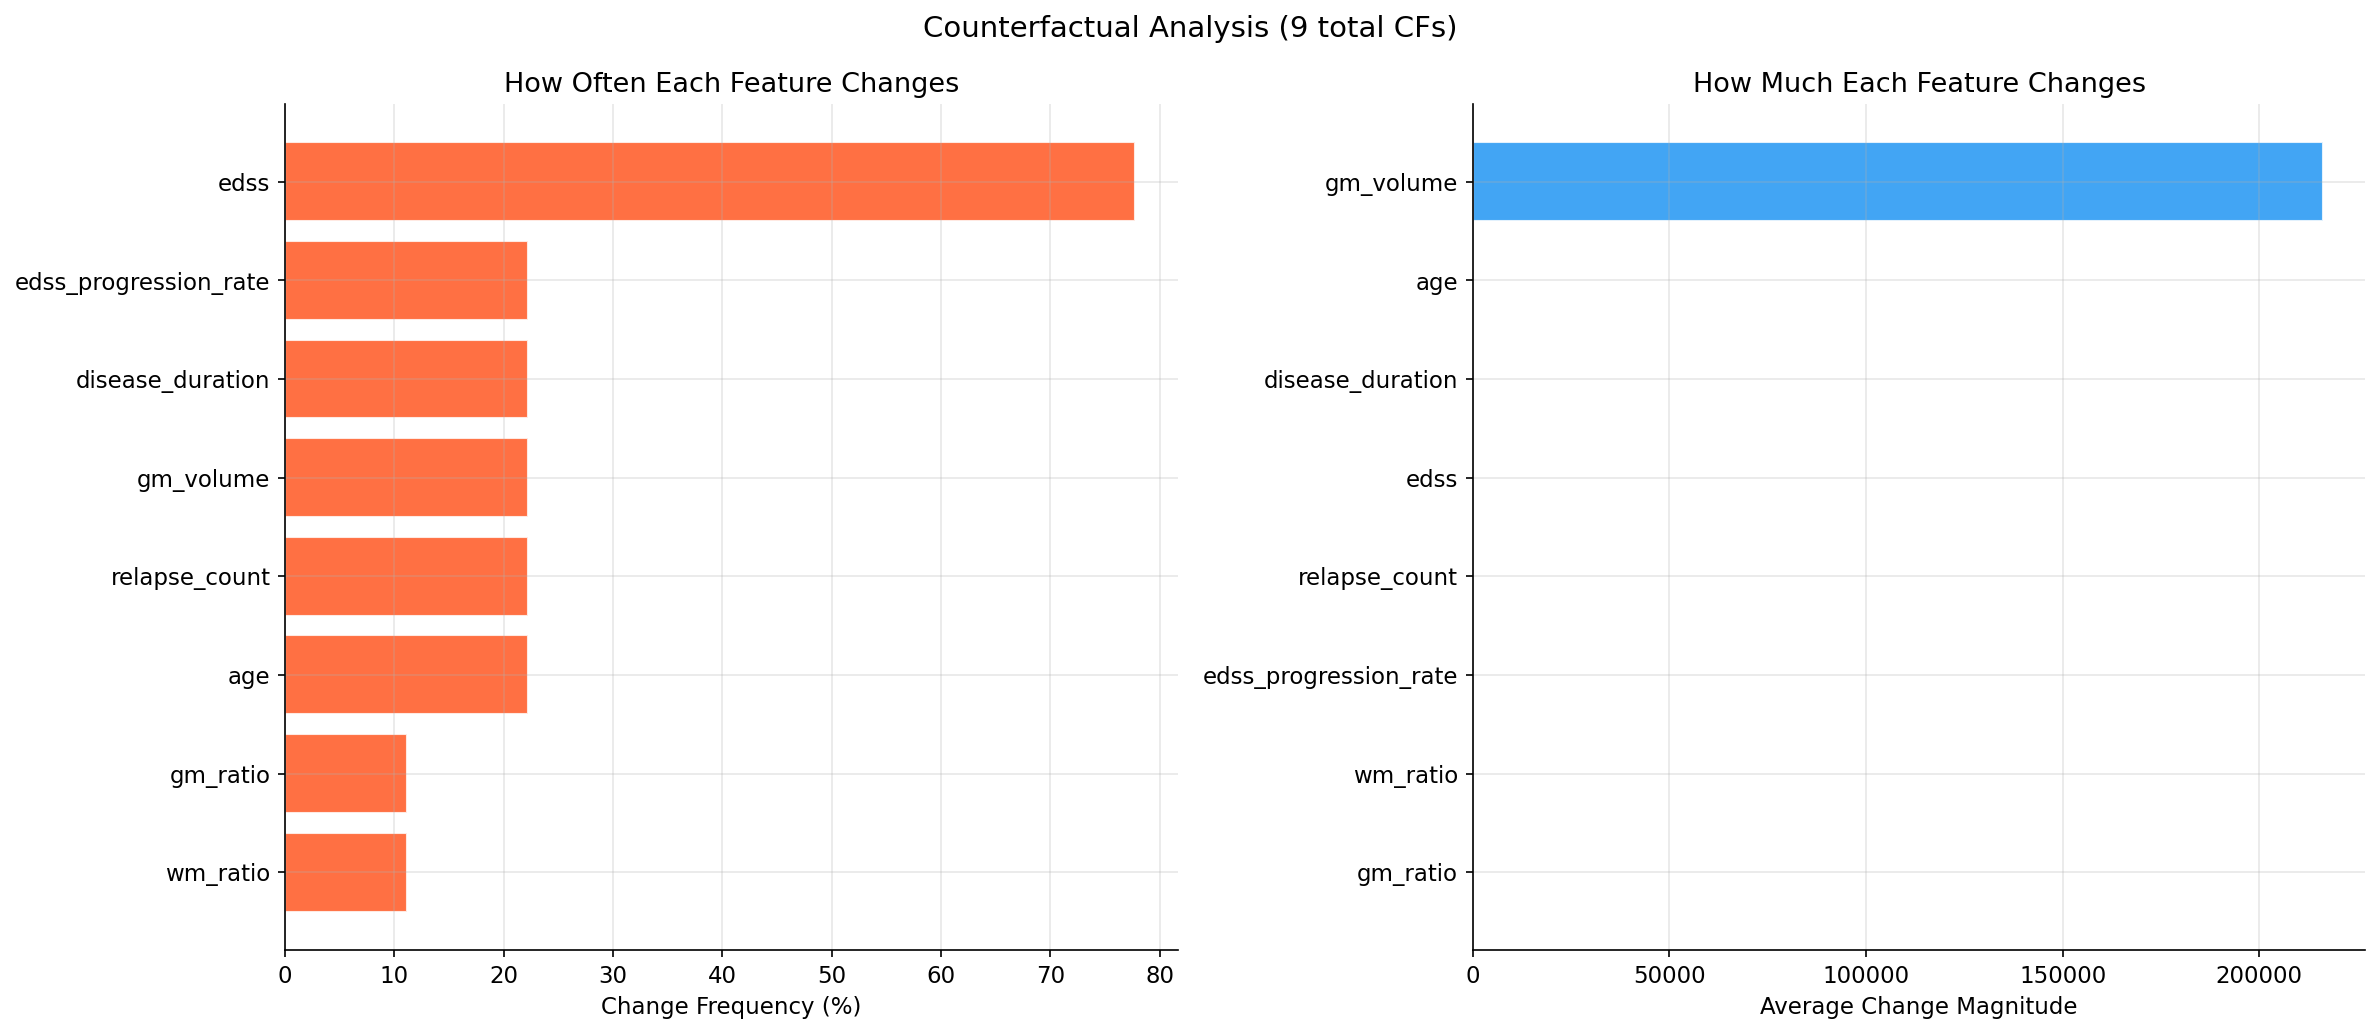

In [14]:
# Analyze feature changes across all counterfactuals
feature_change_counts = {f: 0 for f in feature_cols}
feature_change_magnitudes = {f: [] for f in feature_cols}
total_cfs = 0

for name, data in cf_results.items():
    if data is None:
        continue
    try:
        cf_df = data['cf'].cf_examples_list[0].final_cfs_df
        original = data['patient']
        
        for _, cf_row in cf_df.iterrows():
            total_cfs += 1
            for feat in feature_cols:
                if feat in cf_row and feat in original.columns:
                    orig_val = original[feat].values[0]
                    cf_val = cf_row[feat]
                    if isinstance(cf_val, (int, float)) and abs(cf_val - orig_val) > 1e-6:
                        feature_change_counts[feat] += 1
                        feature_change_magnitudes[feat].append(abs(cf_val - orig_val))
    except Exception:
        pass

if total_cfs > 0:
    change_df = pd.DataFrame({
        'Feature': feature_cols,
        'Change Frequency (%)': [feature_change_counts[f] / total_cfs * 100 for f in feature_cols],
        'Avg Magnitude': [np.mean(feature_change_magnitudes[f]) if feature_change_magnitudes[f] else 0 for f in feature_cols]
    }).sort_values('Change Frequency (%)', ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Frequency
    nonzero = change_df[change_df['Change Frequency (%)'] > 0]
    axes[0].barh(nonzero['Feature'], nonzero['Change Frequency (%)'],
                 color='#FF5722', alpha=0.85, edgecolor='white')
    axes[0].set_xlabel('Change Frequency (%)')
    axes[0].set_title('How Often Each Feature Changes')
    
    # Magnitude
    mag = change_df[change_df['Avg Magnitude'] > 0].sort_values('Avg Magnitude', ascending=True)
    axes[1].barh(mag['Feature'], mag['Avg Magnitude'],
                 color='#2196F3', alpha=0.85, edgecolor='white')
    axes[1].set_xlabel('Average Change Magnitude')
    axes[1].set_title('How Much Each Feature Changes')
    
    plt.suptitle(f'Counterfactual Analysis ({total_cfs} total CFs)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No counterfactuals were generated.")

---
## 13. Most Uncertain Patient — Combined SHAP + Counterfactual

For the patient where the model is least confident, we show both **why** (SHAP) and **what would change it** (counterfactual).

In [15]:
# Find most uncertain patient
proba = model.predict_proba(X_test_ready)
max_proba = proba.max(axis=1)
most_uncertain = np.argmin(max_proba)

patient = X_test_ready.iloc[[most_uncertain]]
true_label = class_names[y_test[most_uncertain]]
pred_label = class_names[y_pred_test[most_uncertain]]
pred_idx = int(y_pred_test[most_uncertain])
probs = proba[most_uncertain]

print(f"Most Uncertain Patient (test index {most_uncertain}):")
print(f"  True: {true_label}, Predicted: {pred_label}")
print(f"  Probabilities: {dict(zip(class_names, probs.round(4)))}")
print(f"  Confidence: {max_proba[most_uncertain]:.1%}")

# SHAP explanation for this patient
print(f"\n--- SHAP: Why {pred_label}? ---")
sv = shap_values_list[pred_idx][most_uncertain]
top_features = np.argsort(np.abs(sv))[-5:][::-1]
for j in top_features:
    direction = "TOWARD" if sv[j] > 0 else "AWAY from"
    print(f"  {feature_cols[j]}: {sv[j]:+.4f} ({direction} {pred_label}, value={patient[feature_cols[j]].values[0]:.2f})")

# Counterfactual for this patient
if true_label != pred_label:
    target_cf_idx = int(list(class_names).index(true_label))
else:
    sorted_probs = sorted(enumerate(probs), key=lambda x: x[1], reverse=True)
    target_cf_idx = int(sorted_probs[1][0])

print(f"\n--- Counterfactual: What would flip to {class_names[target_cf_idx]}? ---")
try:
    cf = dice_exp.generate_counterfactuals(
        patient, total_CFs=3, desired_class=target_cf_idx,
        features_to_vary=continuous_features, random_seed=RANDOM_STATE
    )
    cf.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print(f"  Error: {e}")

Most Uncertain Patient (test index 50):
  True: PPMS, Predicted: SPMS
  Probabilities: {'PPMS': np.float32(0.4804), 'RRMS': np.float32(0.0007), 'SPMS': np.float32(0.5189)}
  Confidence: 51.9%

--- SHAP: Why SPMS? ---
  disease_duration: +0.8764 (TOWARD SPMS, value=19.00)
  lesion_count: +0.7855 (TOWARD SPMS, value=61.00)
  edss_progression_rate: -0.6456 (AWAY from SPMS, value=0.74)
  gm_volume: -0.3921 (AWAY from SPMS, value=523090.40)
  edss: +0.3657 (TOWARD SPMS, value=5.00)

--- Counterfactual: What would flip to PPMS? ---


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:34<00:00, 34.21s/it]

100%|██████████| 1/1 [00:34<00:00, 34.21s/it]

Query instance (original outcome : 2)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,56.0,1.0,37.0,5.0,19.0,0.0,1.0,1308712.625,523090.40625,457434.90625,61.0,14702.599609,0.7358,0.3997,0.3495,0.011234,2



Diverse Counterfactual set (new outcome: 0)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.47613577,-,0.0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.31857928,-,0.0


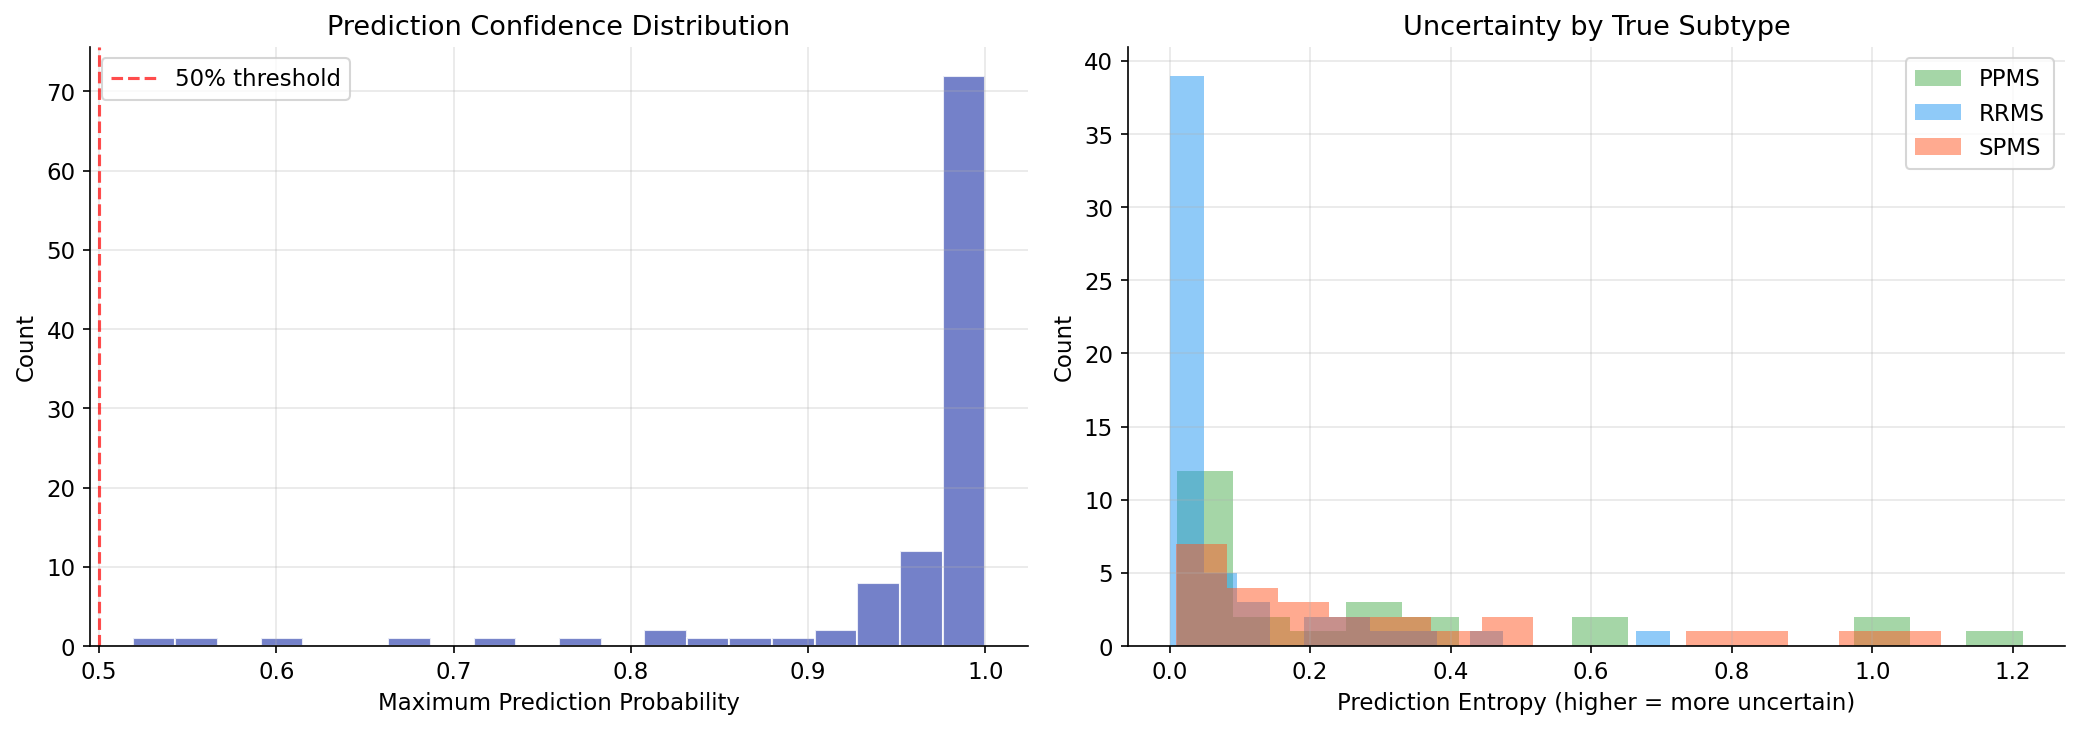

In [16]:
# Prediction confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_proba, bins=20, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='50% threshold')
axes[0].set_xlabel('Maximum Prediction Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution')
axes[0].legend()

for class_idx, name in enumerate(class_names):
    mask = y_test == class_idx
    if mask.sum() > 0:
        entropy = -np.sum(proba[mask] * np.log2(proba[mask] + 1e-10), axis=1)
        axes[1].hist(entropy, bins=15, alpha=0.5, label=name, color=COLORS[name])
axes[1].set_xlabel('Prediction Entropy (higher = more uncertain)')
axes[1].set_ylabel('Count')
axes[1].set_title('Uncertainty by True Subtype')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 14. Summary & Clinical Insights

### SHAP Key Findings

| Rank | Feature | Role |
|------|---------|------|
| 1 | **EDSS** | Strongest discriminator — low EDSS → RRMS, high → SPMS |
| 2 | **Age at Onset** | Late onset pushes toward PPMS |
| 3 | **Age** | Older patients skew toward progressive forms |
| 4 | **Relapse Count** | Zero relapses → PPMS, many → RRMS |
| 5 | **Disease Duration** | Longer duration → SPMS |

### Counterfactual Key Findings

| Transition | Key Changes Needed |
|------------|-------------------|
| **SPMS → RRMS** | Lower EDSS (6→2), shorter disease duration |
| **PPMS → RRMS** | Add relapses (0→2), or: younger age + lower EDSS |
| **RRMS → SPMS** | Higher EDSS, longer disease duration |

### How SHAP and Counterfactuals Complement Each Other

| Aspect | SHAP | Counterfactual |
|--------|------|----------------|
| **Question** | *Why this prediction?* | *What would change it?* |
| **Perspective** | Backward-looking | Forward-looking |
| **Clinical use** | Understanding diagnosis | Treatment planning & monitoring |
| **Output** | Feature contributions | Concrete scenarios |

### Limitations

- Counterfactuals may suggest clinically **infeasible** changes (e.g., reducing disease duration)
- SHAP values are **model-specific** — different models may attribute importance differently
- Both methods analyze the **model**, not the underlying biology
- Clinical validation is essential before using these insights for patient care